# Figure 20.

| Author  | Stanley A. Baronett  |
|---------|----------------------|
| Created |  09/27/2026          |
| Updated |  09/27/2026          |

Similar to Figure 18, except the upper panel only shows grid resolutions at $1024^2$, and the lower panel shows them in black along with $512^2$ in gray.
Shot-noise floors are shown only for particle runs with an initial-state snapshot.

In [1]:
import os
from functools import lru_cache
import matplotlib.pyplot as plt
from matplotlib.legend import Legend
import numpy as np

root = '..'
n_p = 'np1'
times = [20, 50, 100]                           # [T]
L = 2.0                                         # box size [H_g] (SPEC)
LEG = dict(framealpha=0.65, fontsize='small', title_fontsize='small')   # every legend
FLOOR_LS = {f'dust_particles/{n_p}': 'dashdot'}                         # dash-dot
runs = {
    f'dust_particles/{n_p}': {
        'ls': 'dotted',
        'codes': {
            'Athena': 'tab:green', 'Athena++': 'tab:red',
            'Pencil': 'tab:blue', 'PLUTO': 'tab:pink'
        }
    },
    'dust_fluid': {
        'ls': 'solid',
        'codes': {
            'Athena++': 'tab:purple', 'FARGO3D': 'tab:olive',
            'Idefix': 'tab:orange', 'LA-COMPASS': 'tab:cyan',
            'PLUTO': 'tab:brown'
        }
    }
}


In [2]:

def spectrum(path):
    """Shell-summed E(k) of drho_d, SPEC normalization (sum E dk = var)."""
    assert os.path.exists(path), path
    s = np.load(path)
    key = next((k for k in ('rhod', 'rhop', 'dust_density', 'array3') if k in s.files), None)
    assert key is not None, f'{path}: no density key in {s.files}'
    raw = s[key]
    if key != 'rhod' or raw.dtype != np.float64:
        print(f'  note: {path} key={key} {raw.dtype} {raw.shape}; cast to float64')
    rho = raw.astype(np.float64)
    if rho.ndim == 1:
        n = int(round(np.sqrt(rho.size))); assert n*n == rho.size, path
        rho = rho.reshape(n, n)
    assert np.isfinite(rho).all(), f'non-finite values in {path}'
    N = rho.shape[0]; assert rho.shape == (N, N), rho.shape
    kf = 2*np.pi/L
    P = np.abs(np.fft.fft2(rho - rho.mean())/rho.size)**2
    k1 = 2*np.pi*np.fft.fftfreq(N, d=L/N)
    kx, kz = np.meshgrid(k1, k1, indexing='ij')
    n = np.rint(np.hypot(kx, kz)/kf).astype(int)
    E = np.bincount(n.ravel(), P.ravel())
    assert np.isclose(E.sum(), rho.var(), rtol=1e-10), path   # Parseval + overflow
    sl = slice(1, N//2 + 1)
    return kf*np.arange(1, N//2 + 1), E[sl]/kf, rho

@lru_cache(maxsize=None)            # call code_stats.cache_clear() if spectrum() changes
def code_stats(res, key, code):
    """Time-averaged E(k), clipped log-std band, and 0T floor (None if no 0.npz)."""
    path = f'{root}/{res}/src/{key}/{code}'
    out = [spectrum(f'{path}/{t}.npz') for t in times]
    k = out[0][0]
    Es = np.asarray([o[1] for o in out])
    avgs = Es.mean(axis=0)
    stds = np.clip(np.exp(np.std(np.log(Es), axis=0)), None, 3)
    E0 = None
    if key.startswith('dust_particles'):
        if os.path.exists(f'{path}/0.npz'):
            _, E0, rho0 = spectrum(f'{path}/0.npz')
            r = avgs/E0; i = int(np.argmin(r))
            print(f'{res} {key} {code:9s} 0T mean={rho0.mean():.6f} var={rho0.var():.4e} | '
                  f'min <E>/E_0T={r[i]:.2f} at kH={k[i]:.0f} (Nyq {r[-1]:.2f}) | '
                 )
        else:
            print(f'{res} {key} {code:9s} no 0.npz; no floor curve')
    return k, avgs, stds, E0

def add_legend(ax, handles, where, **kw):
    """where: a loc string; a dict of Legend kwargs; or a dict with xy=(kH, E),
    which pins the legend corner named by loc to that data point."""
    where = dict(loc=where) if isinstance(where, str) else dict(where)
    if 'xy' in where:
        where.update(bbox_to_anchor=where.pop('xy'), bbox_transform=ax.transData)
    ax.add_artist(Legend(ax, handles, [h.get_label() for h in handles],
                         **LEG, **where, **kw))

def plot_power_spectrum(top, bottom, ybottom=1e-12, ybottom_lower=None):
    """top: [(res, key, codes, ls, where)], per-code curves, one legend each.
    bottom: [(title, where, alpha, entries)], one legend each; entries are
    (label, res, key, codes, ls), and ls=None plots the mean 0T floor in FLOOR_LS."""
    fig, axs = plt.subplots(nrows=2, sharex=True, figsize=(4, 6), dpi=200)
    kmax = 0
    for res, key, codes, ls, where in top:
        handles = []
        for code, color in codes.items():
            k, avgs, stds, E0 = code_stats(res, key, code)
            handles.append(axs[0].plot(k, avgs, c=color, label=code, ls=ls)[0])
            axs[0].fill_between(k, avgs/stds, avgs*stds, alpha=0.33, color=color, ec=None)
            if E0 is not None:
                axs[0].plot(k, E0, c=color, ls=FLOOR_LS.get(key, 'dashdot'), lw=0.75)
        add_legend(axs[0], handles, where)
        kmax = max(kmax, k[-1])
    for title, where, alpha, entries in bottom:
        handles = []
        for label, res, key, codes, ls in entries:
            floor = ls is None
            stack = []
            for code in codes:
                k, avgs, _, E0 = code_stats(res, key, code)
                E = E0 if floor else avgs
                if E is not None:
                    stack.append(E)
            if not stack:
                continue
            stack = np.asarray(stack)
            mean, std = stack.mean(axis=0), np.exp(np.std(np.log(stack), axis=0))
            handles.append(axs[1].plot(k, mean, c='k', alpha=alpha, label=label,
                                       ls=FLOOR_LS.get(key, 'dashdot') if floor else ls,
                                       lw=0.75 if floor else None)[0])
            axs[1].fill_between(k, mean/std, mean*std, alpha=alpha/3,
                                color='tab:gray', ec=None)
        add_legend(axs[1], handles, where, title=title)
    for ax in axs:
        ax.grid()
        ax.minorticks_on()
        ax.set(xscale='log', yscale='log')
        ax.tick_params(axis='both', which='both', top=True, right=True)
    axs[0].set(ylabel=r'$\overline{E}(k)/(\rho_\mathrm{g,0}^2H)$')
    axs[0].set_ylim(bottom=ybottom)
    if ybottom_lower is not None:
        axs[1].set_ylim(bottom=ybottom_lower)
    axs[1].set(xlim=(2*np.pi/L, kmax), xlabel=r'$kH$',
               ylabel=r'$\overline{\overline{E}}(k)/(\rho_\mathrm{g,0}^2H)$')
    fig.subplots_adjust(hspace=0)
    return fig



  note: ../1024/src/dust_particles/np1/Athena/20.npz key=rhod float32 (1024, 1024); cast to float64
  note: ../1024/src/dust_particles/np1/Athena/50.npz key=rhod float32 (1024, 1024); cast to float64
  note: ../1024/src/dust_particles/np1/Athena/100.npz key=rhod float32 (1024, 1024); cast to float64
1024 dust_particles/np1 Athena    no 0.npz; no floor curve
  note: ../1024/src/dust_particles/np1/Athena++/0.npz key=rhop float64 (1024, 1024); cast to float64
1024 dust_particles/np1 Athena++  0T mean=0.200000 var=1.2060e-02 | min <E>/E_0T=2.37 at kH=1605 (Nyq 2.49) | 
1024 dust_particles/np1 Pencil    0T mean=0.200000 var=1.2105e-02 | min <E>/E_0T=1.67 at kH=1605 (Nyq 1.76) | 


1024 dust_particles/np1 PLUTO     0T mean=0.200000 var=1.2059e-02 | min <E>/E_0T=3.16 at kH=1602 (Nyq 3.37) | 
  note: ../1024/src/dust_fluid/Idefix/20.npz key=rhod >f4 (1024, 1024); cast to float64
  note: ../1024/src/dust_fluid/Idefix/50.npz key=rhod >f4 (1024, 1024); cast to float64
  note: ../1024/src/dust_fluid/Idefix/100.npz key=rhod >f4 (1024, 1024); cast to float64
  note: ../1024/src/dust_fluid/LA-COMPASS/20.npz key=rhod float32 (1024, 1024); cast to float64
  note: ../1024/src/dust_fluid/LA-COMPASS/50.npz key=rhod float32 (1024, 1024); cast to float64
  note: ../1024/src/dust_fluid/LA-COMPASS/100.npz key=rhod float32 (1024, 1024); cast to float64
  note: ../512/src/dust_particles/np1/Athena/20.npz key=rhod float32 (512, 512); cast to float64
  note: ../512/src/dust_particles/np1/Athena/50.npz key=rhod float32 (512, 512); cast to float64
  note: ../512/src/dust_particles/np1/Athena/100.npz key=rhod float32 (512, 512); cast to float64
  note: ../512/src/dust_particles/np1/Athen

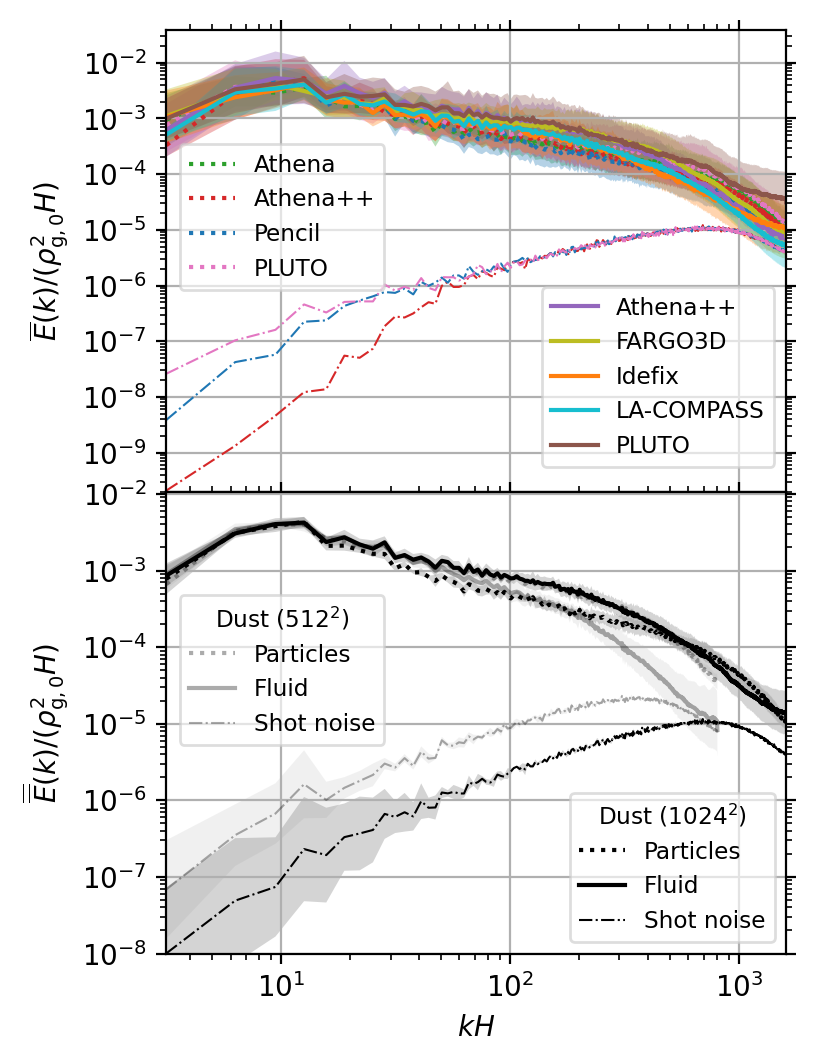

In [3]:
fig20 = plot_power_spectrum(
    top=[(1024, 'dust_particles/np1', runs['dust_particles/np1']['codes'], runs['dust_particles/np1']['ls'], dict(loc='center left', xy=(3.2, 1.7e-5))),
        (1024, 'dust_fluid', runs['dust_fluid']['codes'], runs['dust_fluid']['ls'], dict(loc='upper right', xy=(1600, 1.5e-6)))],
    ybottom=2e-10,
    bottom=[(rf'Dust (${r}^2$)', where, a, [('Particles', r, 'dust_particles/np1', runs['dust_particles/np1']['codes'], runs['dust_particles/np1']['ls']),
                                            ('Fluid', r, 'dust_fluid', runs['dust_fluid']['codes'], runs['dust_fluid']['ls']),
                                            ('Shot noise', r, 'dust_particles/np1', runs['dust_particles/np1']['codes'], None)])
    for r, where, a in ((512, dict(loc='center left', xy=(3.2, 5e-5)), 0.33),
                        (1024, 'lower right', 1))],
    ybottom_lower=1e-8)
